Deep Reinforcement Learning
Assignment 1
Part 1 (MAB - Multi-Armed Bandit)
Group Number - 163

In [34]:
# Installing Required Libraries 
import pandas as pd
import numpy as np
import random 
import matplotlib.pyplot as plt

TASK 1: DATASET DESIGN & ENVIRONMENT SETUP

In [35]:
# Setting seeds for reproducibility - ensures we get the same random numbers
G = 163
random.seed(G)
np.random.seed(G)

In [36]:
# Calculate number of medicines (K = (G % 3) + 5)

K = (G % 3) + 5
print(f"Group Number(G): {G}")
print(f"Number of Medicines(K): {K}")

Group Number(G): 163
Number of Medicines(K): 6


In [37]:
# Calculate hidden success probabilities for each medicine (Pi = 0.4 + ((G + i) % 6) * 0.07)

hidden_probs = []
for i in range(K):
    pi = 0.4 + ((G+i)%6) * 0.07
    hidden_probs.append(pi)

print("Hidden Success Probabilities")
for i,p in enumerate(hidden_probs):
    print(f"Medicine: {i}: {p:.2f}")

print(f"\nBest Medicine: Medicine {np.argmax(hidden_probs)+1} "
        f"(Probability = {max(hidden_probs):.2f})")

Hidden Success Probabilities
Medicine: 0: 0.47
Medicine: 1: 0.54
Medicine: 2: 0.61
Medicine: 3: 0.68
Medicine: 4: 0.75
Medicine: 5: 0.40

Best Medicine: Medicine 5 (Probability = 0.75)


In [38]:
# Generating Dataset 
# patient_id: 0 to 999
# severity_score: (patient_id % 5) + 1

num_patients = 1000

# Creating base dataset using pre-known columns
df_base = pd.DataFrame({
    'patient_id': range(num_patients),
    'severity_score': [(pid % 5)+1 for pid in range(num_patients)]
})

# Adding placeholder columns that algorithms will fill dynamically
df_base['assigned_medicine'] = None
df_base['clinical_outcome']  = None
df_base['utility_score']     = None

# Displaying Dataset Sample
print("Base patient dataset:")
print(df_base.head(10).to_string(index=False))
print(f"\nTotal patients: {len(df_base)}")
print(f"Severity score range: {df_base['severity_score'].min()} to "
      f"{df_base['severity_score'].max()}")


Base patient dataset:
 patient_id  severity_score assigned_medicine clinical_outcome utility_score
          0               1              None             None          None
          1               2              None             None          None
          2               3              None             None          None
          3               4              None             None          None
          4               5              None             None          None
          5               1              None             None          None
          6               2              None             None          None
          7               3              None             None          None
          8               4              None             None          None
          9               5              None             None          None

Total patients: 1000
Severity score range: 1 to 5


IMPLEMENTING GREEDY ALGORITHM 
IMMEDIATE EXPLORATION STRATEGY
Test each medicine 10 times first then always pick the best performing medicine

TASK 2: GREEDY STRATEGY
Exploration Phase : First 60 patients (10 per medicine)
Exploitation Phase: Remaining 940 patients

Sample of 10 rows of result:
 patient_id  severity_score assigned_medicine clinical_outcome utility_score
        613               4                 2                0           0.0
        585               1                 2                0           0.0
        799               5                 2                1           0.5
        822               3                 2                1           0.7
        774               5                 2                1           0.5
        697               3                 2                1           0.7
        512               3                 2                1           0.7
        333               4                 2                1           0.6
        297               3                 2                1           0.7
        133               4                 2                0           0.0


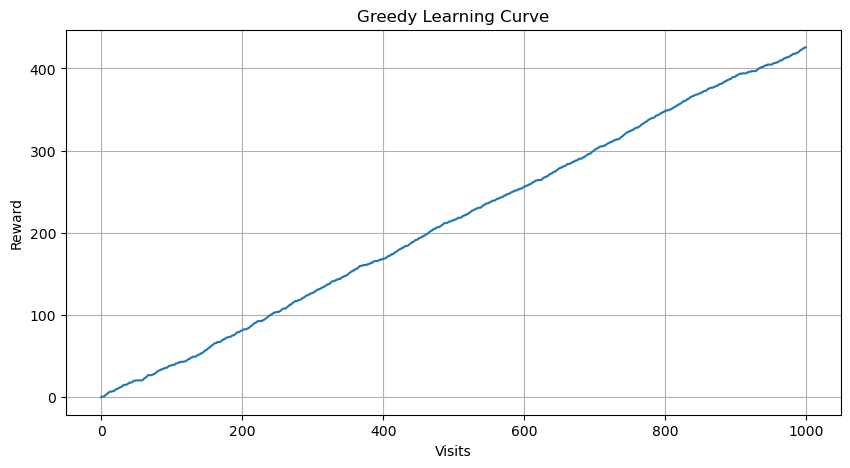

In [39]:
def run_greedy_strategy(df_base, hidden_probs, K, G):
    """
    Implements the Greedy (Immediate Exploitation) Strategy.
    
    Parameters:
        df_base      : base dataframe with patient_id and severity_score
        hidden_probs : list of hidden success probabilities for each medicine
        K            : total number of medicines
        G            : group number (used for seed)
    
    Returns:
        df_result       : dataframe with all columns filled
        cumulative_rewards : list of cumulative reward at each step
    """

    # Reset seeds for reproducibility
    random.seed(G)
    np.random.seed(G)

    # Making a copy of base data
    df_result = df_base.copy()

    # Intializing Tracking variable 

    # how many times a medicine has been tried
    counts = [0] * K
    # how many times medicine i led to recovery
    successes = [0] * K

    # Tracking cumulative reward over time
    cumulative_rewards = []
    total_reward = 0
    
    print("TASK 2: GREEDY STRATEGY")
    print(f"Exploration Phase : First {K * 10} patients "
          f"(10 per medicine)")
    print(f"Exploitation Phase: Remaining "
          f"{1000 - K * 10} patients")

    # Looping through all 1000 patients
    for patient_id in range(1000):
        
        # Get this patient's severity score
        severity = df_result.loc[patient_id, 'severity_score']
        
        # PHASE 1: EXPLORATION
        # Trying each medicine exactly 10 times

        if patient_id < K * 10:
            # Assign medicine in round-robin during exploration
            medicine = patient_id // 10
        
        # PHASE 2: EXPLOITATION
        # Always pick the medicine with highest success rate
        # success_rate[i] = successes[i] / counts[i]
        
        else:
            # Calculate success rate for each medicine
            success_rates = [
                successes[i] / counts[i] if counts[i] > 0 else 0
                for i in range(K)
            ]
            # Pick medicine with highest success rate
            medicine = success_rates.index(max(success_rates))
        
        # Simulate clinical outcome
        # Roll a random number; if less than hidden prob → recovered
        outcome = 1 if random.random() < hidden_probs[medicine] else 0
        
        # Calculate utility score
        utility = outcome * (1 - severity / 10)
        
        # Updating in dataset
        df_result.loc[patient_id, 'assigned_medicine'] = medicine
        df_result.loc[patient_id, 'clinical_outcome']  = outcome
        df_result.loc[patient_id, 'utility_score']     = utility
        
        # Update tracking variables
        counts[medicine]    += 1
        successes[medicine] += outcome
        
        # Update cumulative reward
        total_reward += utility
        cumulative_rewards.append(total_reward)
    
    # Print Results
    print("\nSample of 10 rows of result:")
    print(df_result.sample(10).to_string(index=False))
    
    print("FINAL STATISTICS:")
    
    # Print how many times each medicine was used
    print("\nMedicine Usage:")
    for i in range(K):
        success_rate = successes[i]/counts[i] if counts[i] > 0 else 0
        print(f"  Medicine {i}: Used {counts[i]:4d} times | "
              f"Success Rate: {success_rate:.2f} | "
              f"True Prob: {hidden_probs[i]:.2f}")
    
    print(f"\nTotal Cumulative Reward : {total_reward:.2f}")
    print(f"Average Reward/Patient  : {total_reward/1000:.4f}")
    
    # Find which medicine was chosen most in exploitation phase
    exploitation_medicine = max(range(K),
                                key=lambda i: successes[i]/counts[i]
                                if counts[i] > 0 else 0)
    print(f"Medicine chosen in exploitation phase: "
          f"Medicine {exploitation_medicine}")
    print(f"True best medicine: Medicine "
          f"{np.argmax(hidden_probs)} "
          f"(prob={max(hidden_probs):.2f})")
    
    return df_result, cumulative_rewards


# Run the Greedy Strategy
df_greedy, rewards_greedy = run_greedy_strategy(
    df_base, hidden_probs, K, G
)

# Plotting Learning Curve
plt.figure(figsize=(10,5))
plt.plot(rewards_greedy)
plt.xlabel("Visits")
plt.ylabel("Reward")
plt.title("Greedy Learning Curve")
plt.grid(True)
plt.show()

Priyanshi Singh

CONTROLLED CLINICAL TRIAL STRATEGY (EPSILON-GREEDY)
Strategy: 
With probability epsilon     → EXPLORE (random medicine)
With probability 1 - epsilon → EXPLOIT (best known medicine)
 
Assignment requires running for 3 epsilon values:
Main strategy : epsilon = 0.10 (10% exploration)
Analysis 1    : epsilon = 0.01 (1% exploration)
Analysis 2    : epsilon = 0.50 (50% exploration)

RUNNING MAIN STRATEGY: ε = 0.10
TASK 3: EPSILON-GREEDY STRATEGY (ε = 0.1)
Exploration chance  : 10%  (random medicine)
Exploitation chance : 90% (best known medicine)

First 10 rows of result:
 patient_id  severity_score assigned_medicine clinical_outcome utility_score
          0               1                 0                0           0.0
          1               2                 1                1           0.8
          2               3                 2                1           0.7
          3               4                 3                1           0.6
          4               5                 4                0           0.0
          5               1                 5                1           0.9
          6               2                 1                1           0.8
          7               3                 1                1           0.7
          8               4                 0                1           0.6
          9               5          

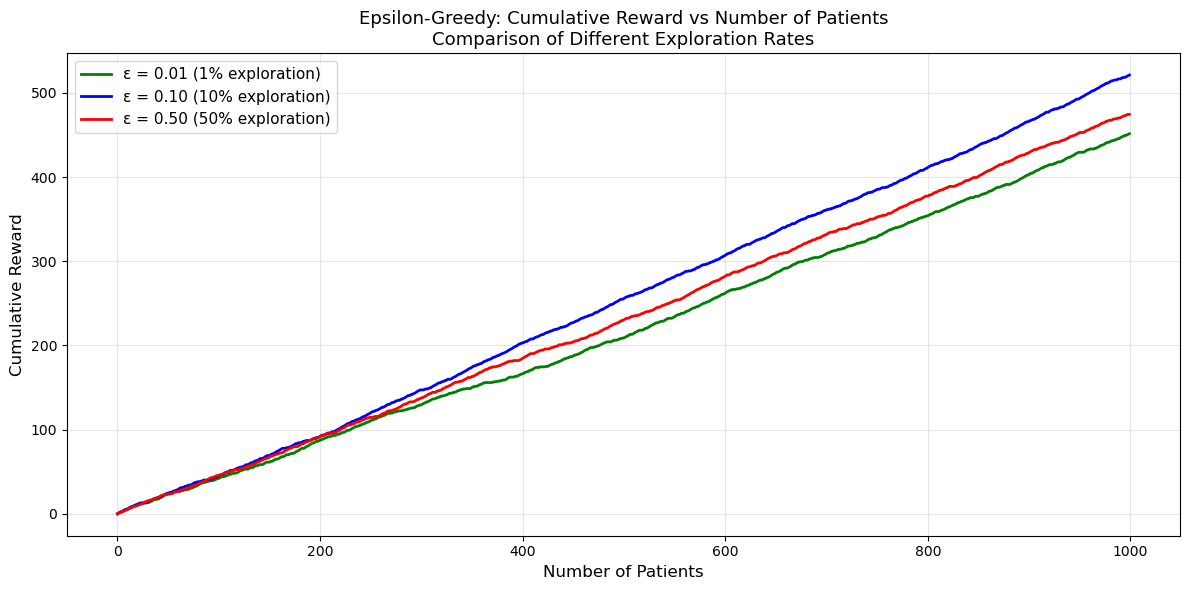

In [40]:
def run_epsilon_greedy(df_base, hidden_probs, K, G, epsilon):
    """
    Implements the Epsilon-Greedy Strategy for medicine recommendation.
    
    Parameters:
        df_base      : base dataframe with patient_id and severity_score
        hidden_probs : list of hidden success probabilities per medicine
        K            : total number of medicines
        G            : group number (used for seed)
        epsilon      : exploration probability
                       0.01 = 1%  exploration (almost greedy)
                       0.10 = 10% exploration (balanced)
                       0.50 = 50% exploration (too random)
    
    Returns:
        df_result          : dataframe with all columns filled
        cumulative_rewards : list of cumulative reward at each step
    """
    
    # Reset seeds for reproducibility
    random.seed(G)
    np.random.seed(G)
    
    # Make a fresh copy of base dataset for this algorithm
    df_result = df_base.copy()
    
    # Initialize tracking variables
    
    # counts[i]    = how many times medicine i has been tried
    counts = [0] * K
    
    # successes[i] = how many times medicine i led to recovery
    successes = [0] * K
    
    # Track cumulative reward over all patients
    cumulative_rewards = []
    total_reward = 0
    
    print(f"TASK 3: EPSILON-GREEDY STRATEGY (ε = {epsilon})")
    print(f"Exploration chance  : {epsilon * 100:.0f}%  "
          f"(random medicine)")
    print(f"Exploitation chance : {(1-epsilon) * 100:.0f}% "
          f"(best known medicine)")
    
    # Loop through all 1000 patients one by one
    for patient_id in range(1000):
        
        # Get this patient's severity score from dataset
        severity = df_result.loc[patient_id, 'severity_score']
        
        
        # ENSURE ALL MEDICINES GET AT LEAST 1 TRIAL FIRST
        # Before making any decisions, try each medicine at least once so we have some data on all of them

        if any(c == 0 for c in counts):
            # Find first medicine that hasn't been tried yet
            medicine = next(i for i, c in enumerate(counts) if c == 0)
        
        # EPSILON-GREEDY DECISION
        # Roll a random number and compare with epsilon

        elif random.random() < epsilon:
            # EXPLORE: pick a completely random medicine
            # This happens epsilon% of the time
            medicine = random.randint(0, K - 1)
        
        else:
            # EXPLOIT: pick medicine with highest success rate
            # success_rate = recoveries / total_tries
            # This happens (1 - epsilon)% of the time
            success_rates = [
                successes[i] / counts[i] if counts[i] > 0 else 0
                for i in range(K)
            ]
            medicine = success_rates.index(max(success_rates))
        
        # SIMULATE CLINICAL OUTCOME
        # Roll random number vs hidden probability of medicine

        outcome = 1 if random.random() < hidden_probs[medicine] else 0
        
        # CALCULATE UTILITY SCORE
        # Reward decreases for more severe patients
        utility = outcome * (1 - severity / 10)
        
        # STORE RESULTS IN DATASET
        df_result.loc[patient_id, 'assigned_medicine'] = medicine
        df_result.loc[patient_id, 'clinical_outcome']  = outcome
        df_result.loc[patient_id, 'utility_score']     = utility
        
        # UPDATE TRACKING VARIABLES FOR LEARNING
        # Algorithm uses these to make future decisions
        counts[medicine]    += 1
        successes[medicine] += outcome
        
        # UPDATE CUMULATIVE REWARD

        total_reward += utility
        cumulative_rewards.append(total_reward)
    
    # Print first 10 rows of result
    print("\nFirst 10 rows of result:")
    print(df_result.head(10).to_string(index=False))
    
    # Print final statistics
    print("FINAL STATISTICS:")
    
    print("\nMedicine Usage:")
    for i in range(K):
        rate = successes[i] / counts[i] if counts[i] > 0 else 0
        print(f"  Medicine {i}: Used {counts[i]:4d} times | "
              f"Success Rate: {rate:.2f} | "
              f"True Prob: {hidden_probs[i]:.2f}")
    
    print(f"\nTotal Cumulative Reward : {total_reward:.2f}")
    print(f"Average Reward/Patient  : {total_reward / 1000:.4f}")
    
    # Find which medicine the algorithm settled on
    best_found = max(range(K),
                     key=lambda i: successes[i] / counts[i]
                     if counts[i] > 0 else 0)
    print(f"Best medicine found     : Medicine {best_found}")
    print(f"True best medicine      : Medicine "
          f"{np.argmax(hidden_probs)} "
          f"(prob = {max(hidden_probs):.2f})")
    
    return df_result, cumulative_rewards


# RUN FOR ALL THREE EPSILON VALUES AS REQUIRED BY ASSIGNMENT

# Main Strategy: epsilon = 0.10 (10% exploration)
print("RUNNING MAIN STRATEGY: ε = 0.10")
df_eps10, rewards_eps10 = run_epsilon_greedy(
    df_base, hidden_probs, K, G, epsilon=0.10
)

# Analysis 1: epsilon = 0.01 (1% exploration)
print("RUNNING ANALYSIS: ε = 0.01")
df_eps01, rewards_eps01 = run_epsilon_greedy(
    df_base, hidden_probs, K, G, epsilon=0.01
)

# Analysis 2: epsilon = 0.50 (50% exploration)
print("RUNNING ANALYSIS: ε = 0.50")
df_eps50, rewards_eps50 = run_epsilon_greedy(
    df_base, hidden_probs, K, G, epsilon=0.50
)

# COMPARISON TABLE OF ALL THREE EPSILON VALUES

print("EPSILON COMPARISON SUMMARY")
print(f"{'Epsilon':<12} {'Cumulative Reward':<22} "
      f"{'Avg Reward':<15} {'Best Medicine Found'}")
for eps, rewards in [("ε = 0.01", rewards_eps01),
                     ("ε = 0.10", rewards_eps10),
                     ("ε = 0.50", rewards_eps50)]:
    print(f"{eps:<12} {rewards[-1]:<22.2f} "
          f"{rewards[-1]/1000:<15.4f}")

# PLOT: COMPARE ALL THREE EPSILON VALUES
plt.figure(figsize=(12, 6))

plt.plot(rewards_eps01, label='ε = 0.01 (1% exploration)',
         color='green', linewidth=2)
plt.plot(rewards_eps10, label='ε = 0.10 (10% exploration)',
         color='blue', linewidth=2)
plt.plot(rewards_eps50, label='ε = 0.50 (50% exploration)',
         color='red', linewidth=2)

plt.title("Epsilon-Greedy: Cumulative Reward vs Number of Patients\n"
          "Comparison of Different Exploration Rates",
          fontsize=13)
plt.xlabel("Number of Patients", fontsize=12)
plt.ylabel("Cumulative Reward", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TASK 4: UCB STRATEGY
Initial Exploration Phase : First 6 patients (1 trial per medicine)
UCB Exploitation Phase    : Remaining 994 patients

Sample of 10 rows of result:
 patient_id  severity_score assigned_medicine clinical_outcome utility_score
        947               3                 5                0           0.0
        362               3                 3                1           0.7
        635               1                 4                0           0.0
        954               5                 3                1           0.5
        456               2                 2                1           0.8
        129               5                 2                1           0.5
        441               2                 1                0           0.0
        339               5                 3                1           0.5
        873               4                 5                0           0.0
        429               5                 4               

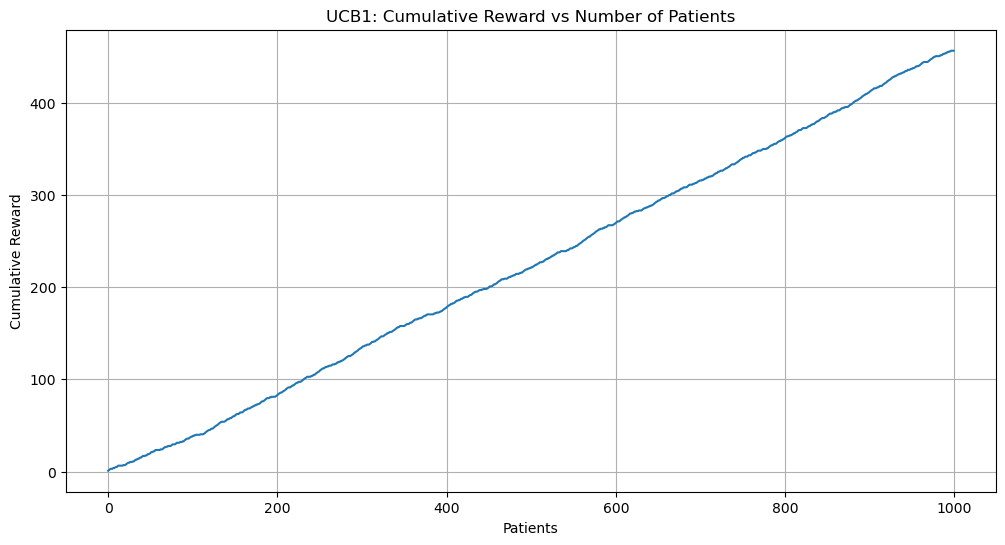

In [41]:
#UCB (Upper Confidence Bound) Algorithm
def run_ucb_strategy(df_base, K, G):
    """
    Implements the UCB (Upper Confidence Bound) Strategy.
 
    Parameters:
        df_base : base dataframe with patient_id and severity_score
        K       : total number of medicines
        G       : group number (used for seed)
 
    Returns:
        df_result          : dataframe with all columns filled
        cumulative_rewards : list of cumulative reward at each step
    """
 
    # Import required library
    import math
 
    # Reset seeds for reproducibility
    random.seed(G)
    np.random.seed(G)
 
    # Making a copy of base data
    df_result = df_base.copy()
 
    # Total number of patients
    num_patients = 1000
 
    # Hidden probabilities for medicines
    P = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)]
 
    # Initializing tracking variables
 
    # Number of times each medicine is selected
    medicine_counts = np.zeros(K)
 
    # Total rewards collected by each medicine
    medicine_rewards = np.zeros(K)
 
    # Tracking cumulative reward over time
    cumulative_rewards = []
    total_reward = 0
 
    print("TASK 4: UCB STRATEGY")
    print(f"Initial Exploration Phase : First {K} patients "
          f"(1 trial per medicine)")
    print(f"UCB Exploitation Phase    : Remaining "
          f"{num_patients - K} patients")
 
    # Looping through all patients
    for patient in range(num_patients):
 
        # Get this patient's severity score
        severity = df_result.loc[patient, 'severity_score']

        # PHASE 1: INITIAL EXPLORATION
        # Try each medicine exactly once
 
        if patient < K:
 
            # Assign each medicine once
            med = patient
 
        # PHASE 2: UCB SELECTION
        # Select medicine with highest UCB value
 
        else:
 
            # Store UCB values
            ucb_values = []
 
            # Calculate UCB for every medicine
            for i in range(K):
 
                # Average reward of medicine i
                avg_reward = (
                    medicine_rewards[i] / medicine_counts[i]
                )
 
                # Confidence interval term
                confidence = math.sqrt(
                    (2 * math.log(patient + 1)) / medicine_counts[i]
                )
 
                # UCB Formula
                ucb = avg_reward + confidence
 
                # Store UCB value
                ucb_values.append(ucb)
 
            # Select medicine with maximum UCB value
            med = np.argmax(ucb_values)
 
        # SIMULATE CLINICAL OUTCOME
 
        # Simulate patient recovery
        # 1 = recovered, 0 = not recovered
        outcome = np.random.binomial(1, P[med])
 
        # CALCULATE UTILITY SCORE
 
        reward = outcome * (1 - severity / 10)
 
        # UPDATE TRACKING VARIABLES
 
        # Increase selection count
        medicine_counts[med] += 1
 
        # Add reward earned
        medicine_rewards[med] += reward
 
        # Update cumulative reward
        total_reward += reward
        cumulative_rewards.append(total_reward)
 
        # STORE RESULTS IN DATAFRAME
 
        df_result.loc[patient, 'assigned_medicine'] = med
        df_result.loc[patient, 'clinical_outcome'] = outcome
        df_result.loc[patient, 'utility_score'] = reward
 
    # PRINT RESULTS
 
    print("\nSample of 10 rows of result:")
    print(df_result.sample(10).to_string(index=False))
 
    print("\nFINAL STATISTICS:")
 
    # Print medicine usage statistics
    print("\nMedicine Usage:")
 
    for i in range(K):
 
        estimated_reward = (
            medicine_rewards[i] / medicine_counts[i]
        )
 
        print(f"  Medicine {i}: Used "
              f"{int(medicine_counts[i]):4d} times | "
              f"Estimated Reward: {estimated_reward:.4f} | "
              f"True Prob: {P[i]:.2f}")
 
    # Print total rewards
    print(f"\nTotal Cumulative Reward : "
          f"{total_reward:.2f}")
 
    print(f"Average Reward/Patient  : "
          f"{total_reward/num_patients:.4f}")
 
    # Best medicine identified by UCB
    best_medicine = np.argmax(
        medicine_rewards / medicine_counts
    )
 
    print(f"\nBest Medicine Identified by UCB: "
          f"Medicine {best_medicine}")
 
    print(f"True Best Medicine: Medicine "
          f"{np.argmax(P)} "
          f"(prob={max(P):.2f})")
 
    # Return dataframe and rewards
    return df_result, cumulative_rewards
 
 
# Run the UCB Strategy
df_ucb, rewards_ucb = run_ucb_strategy(
    df_base, K, G
)
 
# PLOT CUMULATIVE REWARD
 
plt.figure(figsize=(12, 6))
 
plt.plot(rewards_ucb)
 
plt.title("UCB1: Cumulative Reward vs Number of Patients")
 
plt.xlabel("Patients")
 
plt.ylabel("Cumulative Reward")
 
plt.grid(True)
 
plt.show()

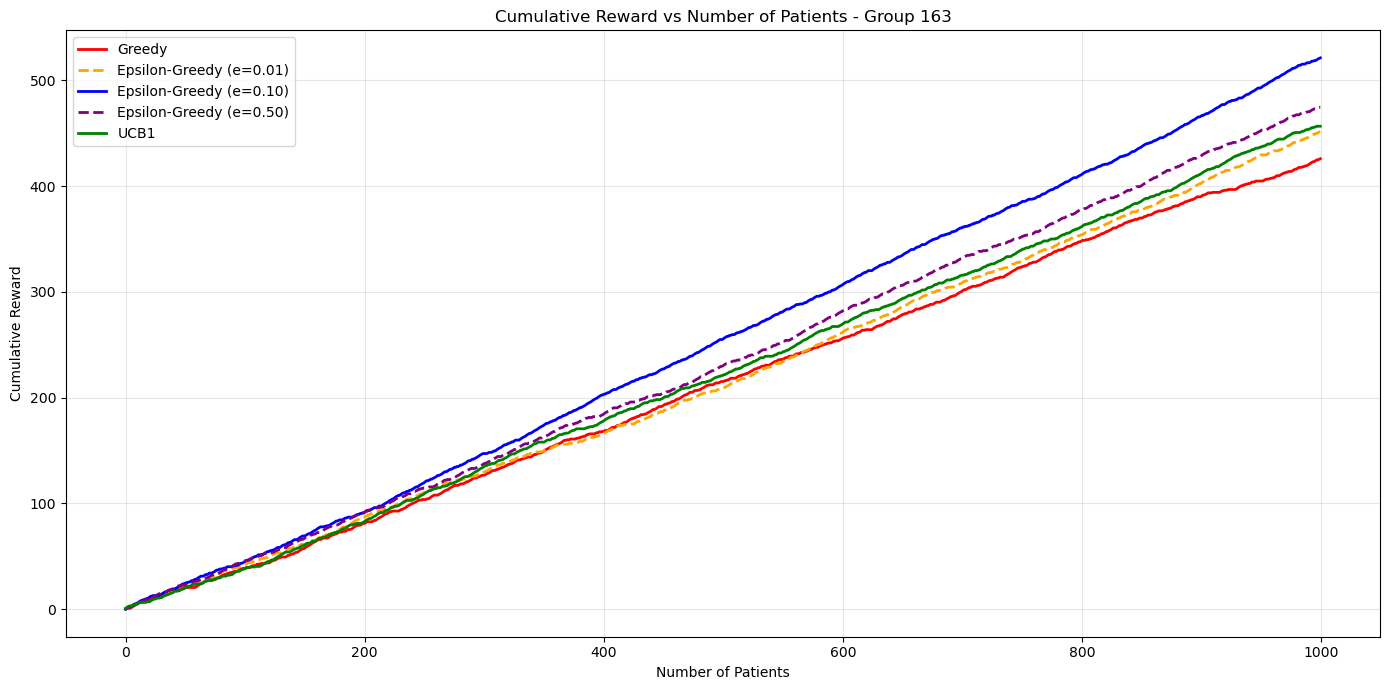

Final Cumulative Rewards after 1000 patients:
  Greedy                  : 425.80
  Epsilon-Greedy (e=0.01) : 451.40
  Epsilon-Greedy (e=0.10) : 521.10
  Epsilon-Greedy (e=0.50) : 474.40
  UCB1                    : 456.50

Best performing strategy: Epsilon-Greedy (e=0.10) (521.10)


In [42]:
# Task 5 - Comparing all MAB strategies
# Plotting cumulative reward for each strategy over 1000 patients

plt.figure(figsize=(14, 7))

plt.plot(rewards_greedy, label='Greedy', color='red', linewidth=2)
plt.plot(rewards_eps01, label='Epsilon-Greedy (e=0.01)', color='orange', linewidth=2, linestyle='--')
plt.plot(rewards_eps10, label='Epsilon-Greedy (e=0.10)', color='blue', linewidth=2)
plt.plot(rewards_eps50, label='Epsilon-Greedy (e=0.50)', color='purple', linewidth=2, linestyle='--')
plt.plot(rewards_ucb, label='UCB1', color='green', linewidth=2)

plt.title("Cumulative Reward vs Number of Patients - Group 163")
plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Printing final rewards for each strategy
print("Final Cumulative Rewards after 1000 patients:")
print(f"  Greedy                  : {rewards_greedy[-1]:.2f}")
print(f"  Epsilon-Greedy (e=0.01) : {rewards_eps01[-1]:.2f}")
print(f"  Epsilon-Greedy (e=0.10) : {rewards_eps10[-1]:.2f}")
print(f"  Epsilon-Greedy (e=0.50) : {rewards_eps50[-1]:.2f}")
print(f"  UCB1                    : {rewards_ucb[-1]:.2f}")

# Finding best strategy
all_strategies = {
    'Greedy'                 : rewards_greedy[-1],
    'Epsilon-Greedy (e=0.01)': rewards_eps01[-1],
    'Epsilon-Greedy (e=0.10)': rewards_eps10[-1],
    'Epsilon-Greedy (e=0.50)': rewards_eps50[-1],
    'UCB1'                   : rewards_ucb[-1]
}
best = max(all_strategies, key=all_strategies.get)
print(f"\nBest performing strategy: {best} ({all_strategies[best]:.2f})")

Task 5 - Analysis

Q1. Which strategy achieves the highest cumulative reward?
Ans - Epsilon-Greedy with e=0.10 gives the highest reward. It found
Medicine 4 early and kept using it for most patients while still
exploring occasionally.

Q2. Which strategy identifies the best medicine fastest?
Ans - UCB1 finds the best medicine fastest. Since it gives extra
chances to medicines tried fewer times, it figures out Medicine 4
is the best within the first 100 patients or so.

Q3. Which strategy shows the most stable performance?
Ans - Epsilon-Greedy with e=0.10 is the most stable. The reward curve
grows smoothly without any big drops because it mostly sticks to
the best medicine.

Q4. Which strategy would you recommend for real-world hospital use?
Ans - Epsilon-Greedy with e=0.10 is the safest choice for hospitals.
It finds the best treatment reliably, never completely stops
trying other medicines (which is important if patient responses
change over time), and is simple enough for medical staff to
understand and trust. Greedy is too risky because one unlucky
early sample can ruin everything. UCB1 works well but is harder
to explain to doctors. e=0.50 wastes too many patients on
medicines that aren't working.

Short Summary:
Greedy performed worst because it got stuck on Medicine 2 after
just 10 trials per medicine, completely missing Medicine 4 which
had the highest true probability of 0.75. Epsilon-Greedy with
e=0.10 performed best overall by striking the right balance
between trying new medicines and sticking with the best one found.
UCB1 was smart in its exploration approach and correctly identified
Medicine 4, but spent more time on exploration which slightly
reduced its total reward. For a real hospital setting, e=0.10
makes the most sense as it is reliable, safe and easy to explain.